In [1]:
from astropy.table import Table 
import numpy as np

# load data onto an astropy table

jades_path = '/home/caltech-msanche3/data/JADES_south_fits_data.fits'
jades_data = Table.read(jades_path, hdu='KRON_CONV',format='fits')
# change units of flux from nJy to microJy so eazy fits correctly
for col in jades_data.colnames:
    if '_KRON' in col or '_ei' in col:
        jades_data[col] = jades_data[col] * 0.001
redshift = Table.read(jades_path, hdu='PHOTOZ_KRON',format='fits')

In [2]:
'''
for i in range(len(jades_data)):
    print(jades_data[i]['ID','RA','DEC'])
    print(redshift[i]['ID','z_a'])

'''
# ID 12326 is likely not correct and I will be ommiting it for the time being
# there are outliers in this list
# total objs: 22
ids = [166539,96216,135819,131688,127219,27503,140125,318988,131971,107324,265801,14376,169896]
zspec = [6.18,12.48,7.04,6.33,6.63,8.19,6.92,6.04,6.32,9.68,9.43,7.96,6.16]
jades_zphot = [6.54,15.26,7.07,6.34,6.57,8.55,7.47,6.27,6.49,9.44,9.44,8.5,6.56]
mask = []
for i in range(len(jades_data)):
    if jades_data[i]['ID'] in ids:
        mask.append(True)
    else:
        mask.append(False)

zspec_ordered = [7.96,8.19,12.48,9.68,6.63,6.33,6.32,7.04,6.92,6.18,6.16,9.43,6.04]
new_jades_data = jades_data[mask]
new_jades_data.add_column(zspec_ordered,name='ZSPEC',index=2)
print(new_jades_data)

'''
n = np.where(jades_data['ID']==159179)[0]
print(jades_data[n]['ID','RA','DEC'])
print(redshift[n]['ID','z_a'])
'''

  ID       RA    ZSPEC ...    F850LP_KRON_S_ei      F850LP_KRON_S_bkg   
          deg          ...          nJy                    nJy          
------ --------- ----- ... --------------------- -----------------------
 14376 53.076694  7.96 ...  0.005301977636882984   0.0012178814369334533
 27503 53.075806  8.19 ...  0.004283003531880568 -0.00042230131867644106
 96216 53.166344 12.48 ... 0.0010897066939173391  -0.0014571633366465093
107324 53.167355  9.68 ... 0.0011150794666141331  -0.0005012977723402228
127219  53.16905  6.63 ... 0.0011983378663814174  -0.0003565267415545693
131688  53.13492  6.33 ...  0.004648926514494667  -0.0009271082041169444
131971   53.1666  6.32 ... 0.0013738568748647836  -0.0003594379519226296
135819 53.134228  7.04 ...  0.004705862800015319  -0.0008190402936888263
140125 53.117302  6.92 ...  0.005204843081706954   -0.001024302985573342
166539 53.092876  6.18 ...  0.046408748050303324   -0.038908897323900425
169896 53.091164  6.16 ...  0.005991526444502631   

"\nn = np.where(jades_data['ID']==159179)[0]\nprint(jades_data[n]['ID','RA','DEC'])\nprint(redshift[n]['ID','z_a'])\n"

In [3]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = new_jades_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 5
params['Z_MAX'] = 15
params['IGM_SCALE_TAU'] = 1.0
params['FIX_ZSPEC'] = True
params['PRIOR_ABZP'] = 23.90

# 2. Tell it what templates to use to fit the light

params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/fsps_full/tweak_fsps_QSF_12_v3.param"
# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'JADES_south_control_fit'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/jades_trans_file.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 13
F070W_KRON F070W_KRON_ei (362): jwst_nircam_f070w
F090W_KRON F090W_KRON_ei (363): jwst_nircam_f090w
F105W_KRON F105W_KRON_ei (202): hst/wfc3/IR/f105w.dat
F115W_KRON F115W_KRON_ei (364): jwst_nircam_f115w
F125W_KRON F125W_KRON_ei (203): hst/wfc3/IR/f125w.dat
F140W_KRON F140W_KRON_ei (204): hst/wfc3/IR/f140w.dat
F150W_KRON F150W_KRON_ei (365): jwst_nircam_f150w
F160W_KRON F160W_KRON_ei (205): hst/wfc3/IR/f160w.dat
F162M_KRON F162M_KRON_ei (369): jwst_nircam_f162m
F182M_KRON F182M_KRON_ei (370): jwst_nircam_f182m
F200W_KRON F200W_KRON_ei (366): jwst_nircam_f200w
F210M_KRON F210M_KRON_ei (371): jwst_nircam_f210m
F250M_KRON F250M_KRON_ei (379): jwst_nircam_f250m
F277W_KRON F277W_KRON_ei (375): jwst_nircam_f277w
F300M_KRON F300M_KRON_ei (3

100%|██████████| 12/12 [00:16<00:00,  1.41s/it]


Template   0: tweak_fsps_QSF_12_v3_001.dat (NZ=1).
Template   1: tweak_fsps_QSF_12_v3_002.dat (NZ=1).
Template   2: tweak_fsps_QSF_12_v3_003.dat (NZ=1).
Template   3: tweak_fsps_QSF_12_v3_004.dat (NZ=1).
Template   4: tweak_fsps_QSF_12_v3_005.dat (NZ=1).
Template   5: tweak_fsps_QSF_12_v3_006.dat (NZ=1).
Template   6: tweak_fsps_QSF_12_v3_007.dat (NZ=1).
Template   7: tweak_fsps_QSF_12_v3_008.dat (NZ=1).
Template   8: tweak_fsps_QSF_12_v3_009.dat (NZ=1).
Template   9: tweak_fsps_QSF_12_v3_010.dat (NZ=1).
Template  10: tweak_fsps_QSF_12_v3_011.dat (NZ=1).
Template  11: tweak_fsps_QSF_12_v3_012.dat (NZ=1).
Process templates: 19.067 s


99it [00:00, 25866.57it/s]

Fitting program initialized successfully!


In [4]:
#ez.fit_catalog(ez.idx[mask],n_proc=16)
ez.cat['z_spec'] = new_jades_data['ZSPEC']
ez.fit_catalog(ez.idx,n_proc=16)

100%|██████████| 99/99 [00:00<00:00, 5767.97it/s]

Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=13)
Fit 0.3 s (n_proc=16, NOBJ=13)


In [5]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 0.0 s (n_proc=1,  NOBJ=13)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 238.03it/s]

CALLED TWk


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


<>:56: SyntaxWarning: invalid escape sequence '\c'
<>:56: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2274761/2246036097.py:56: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}",


[9, 2, 7, 5, 4, 1, 8, 12, 6, 3, 11, 0, 10]


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


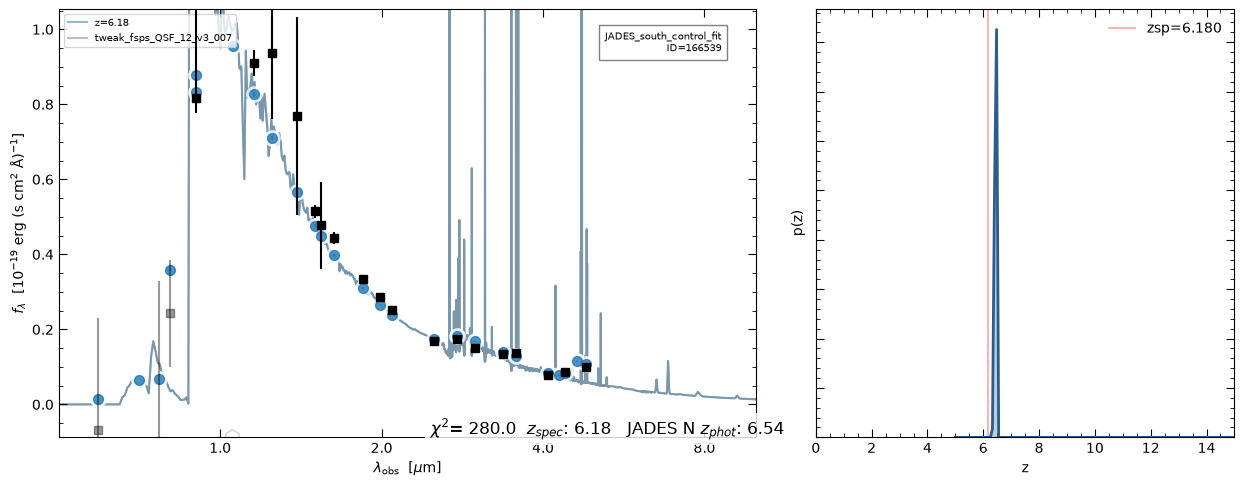

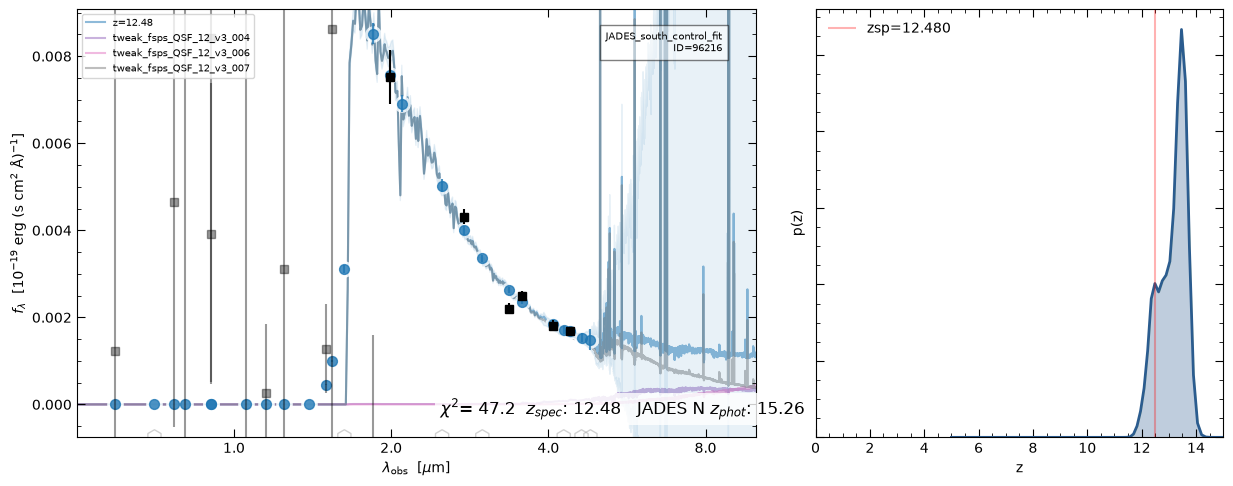

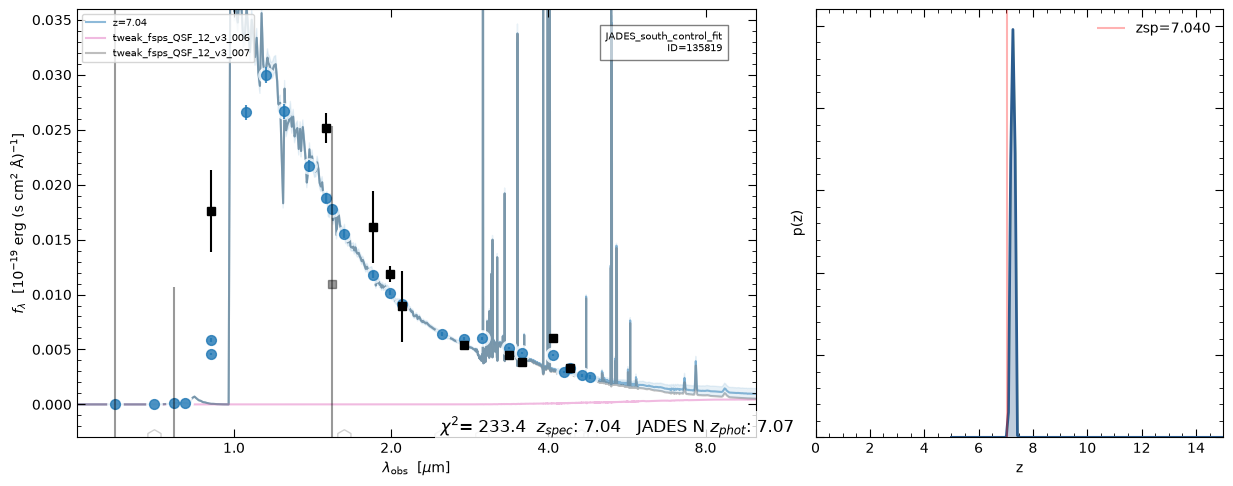

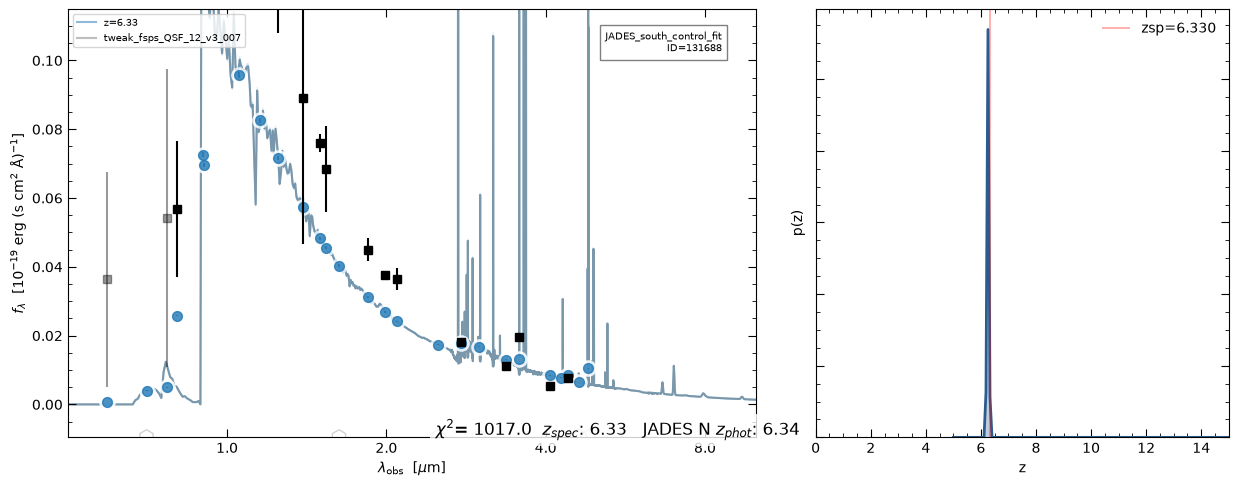

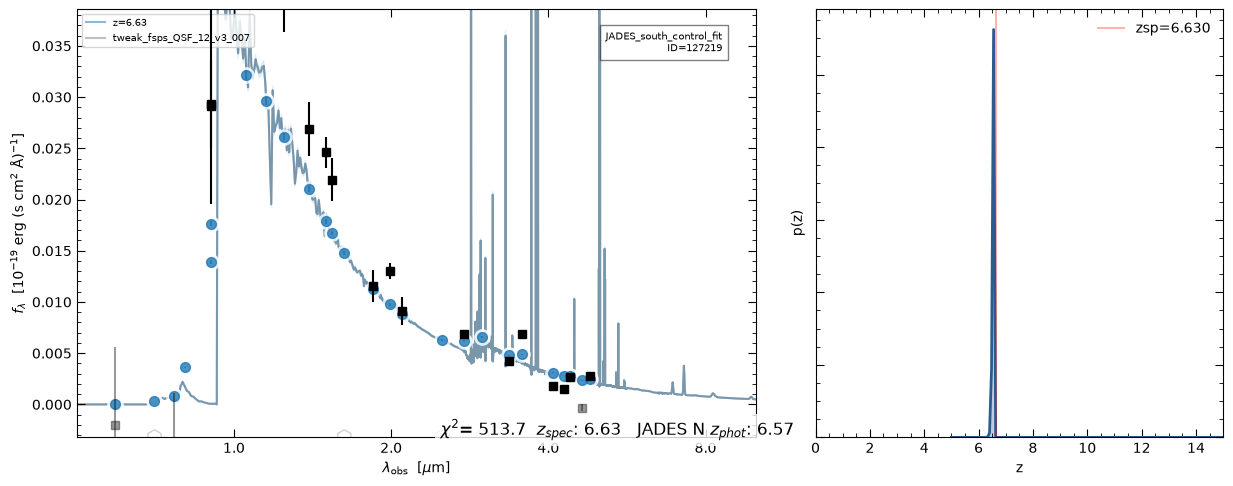

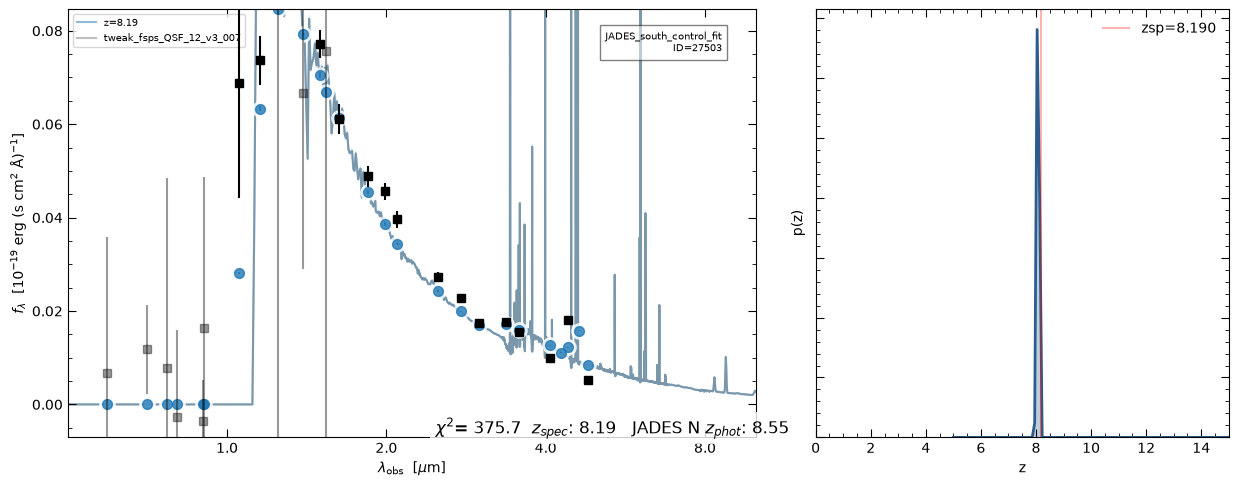

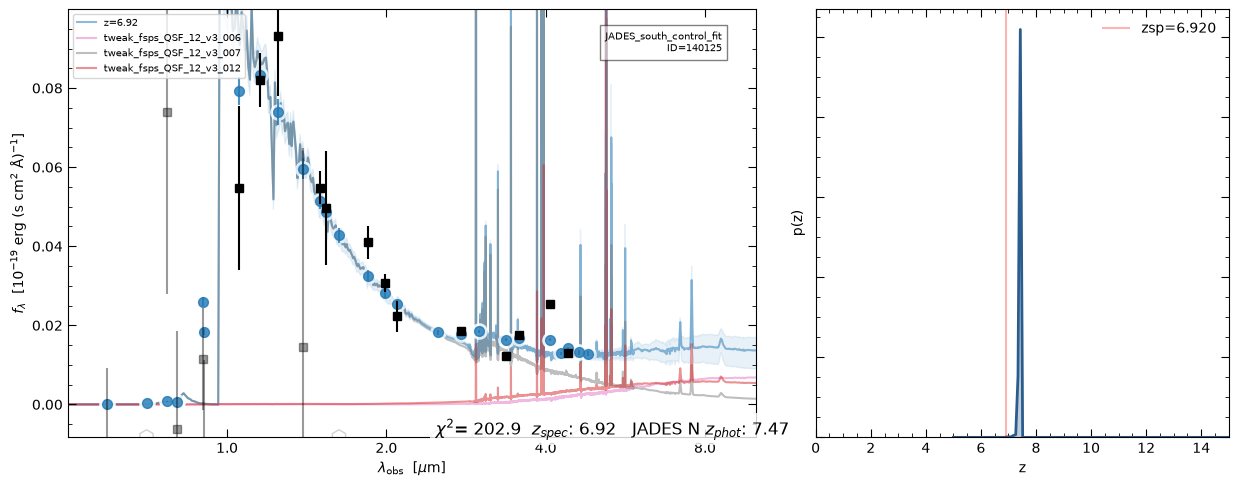

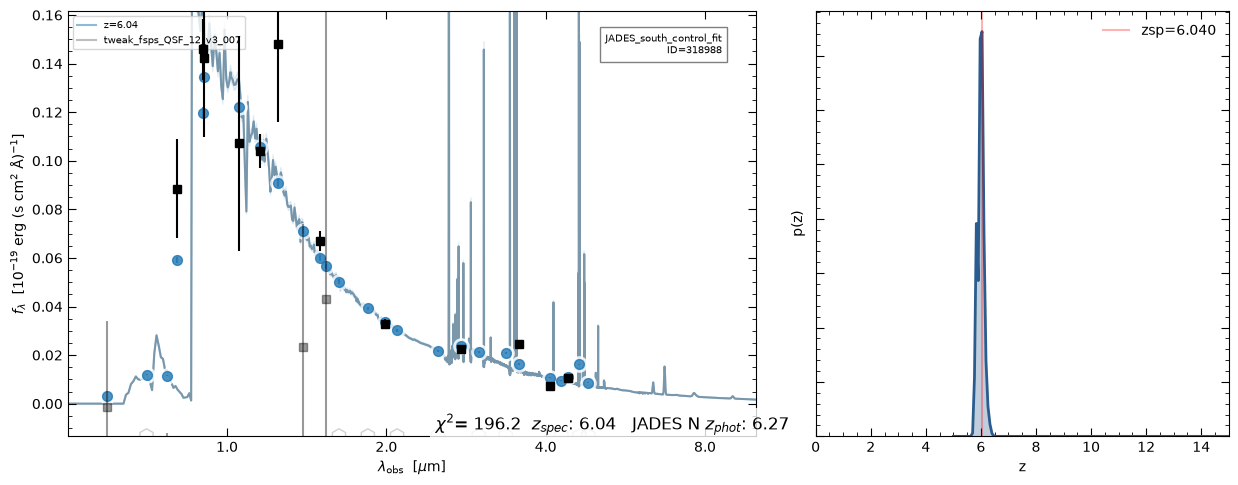

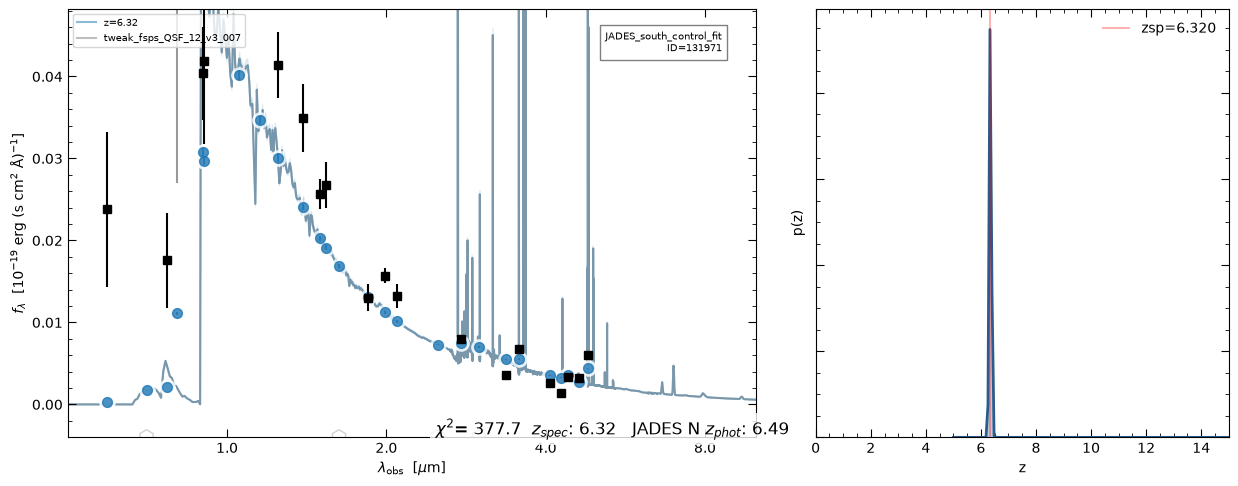

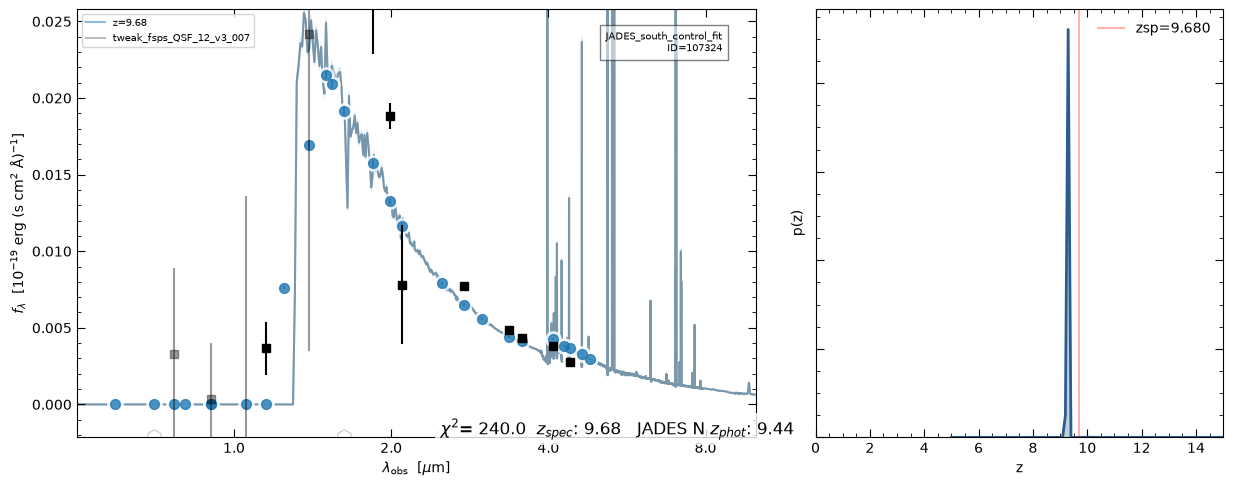

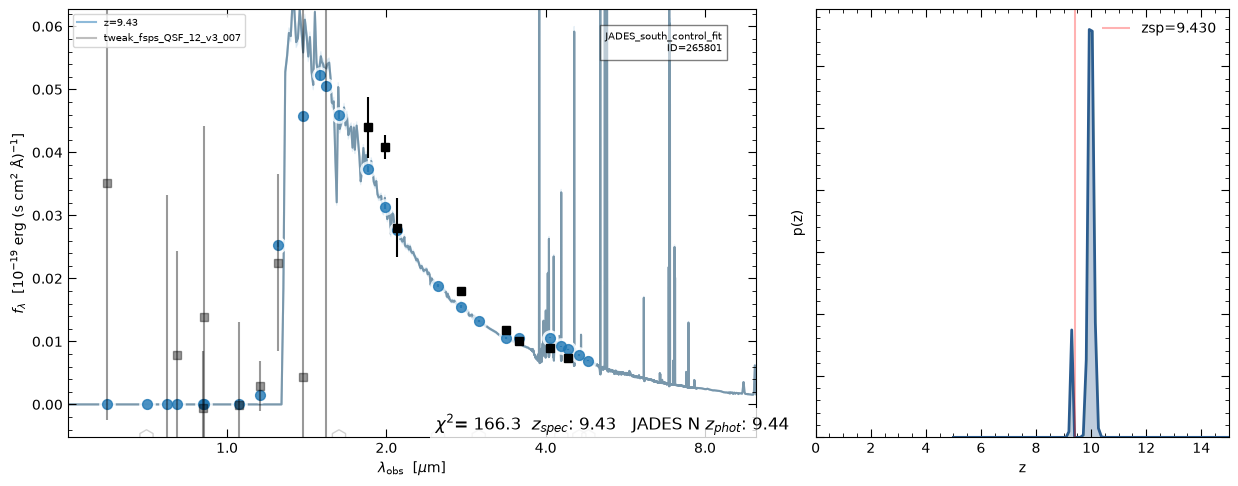

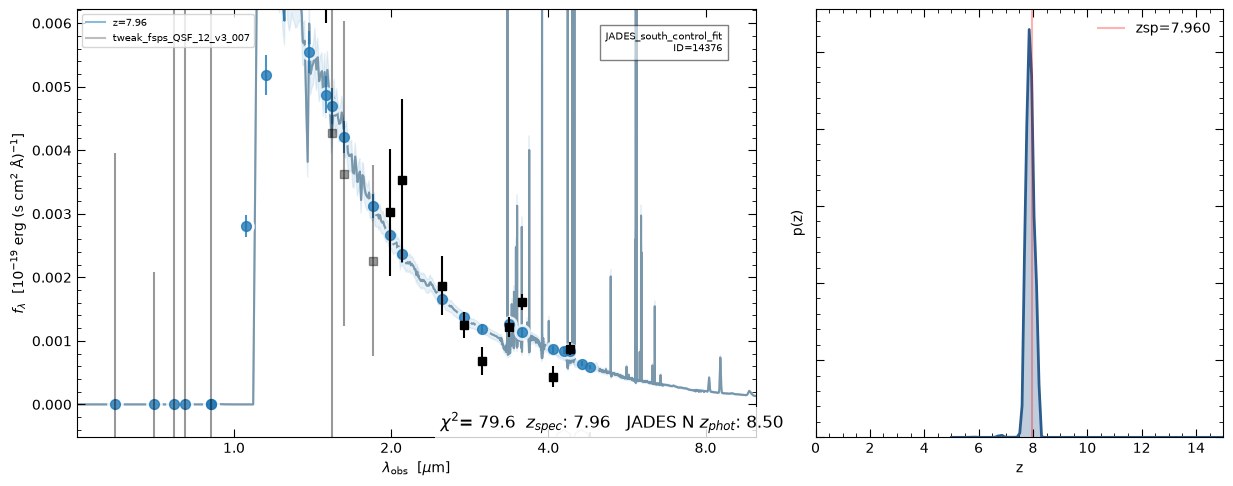

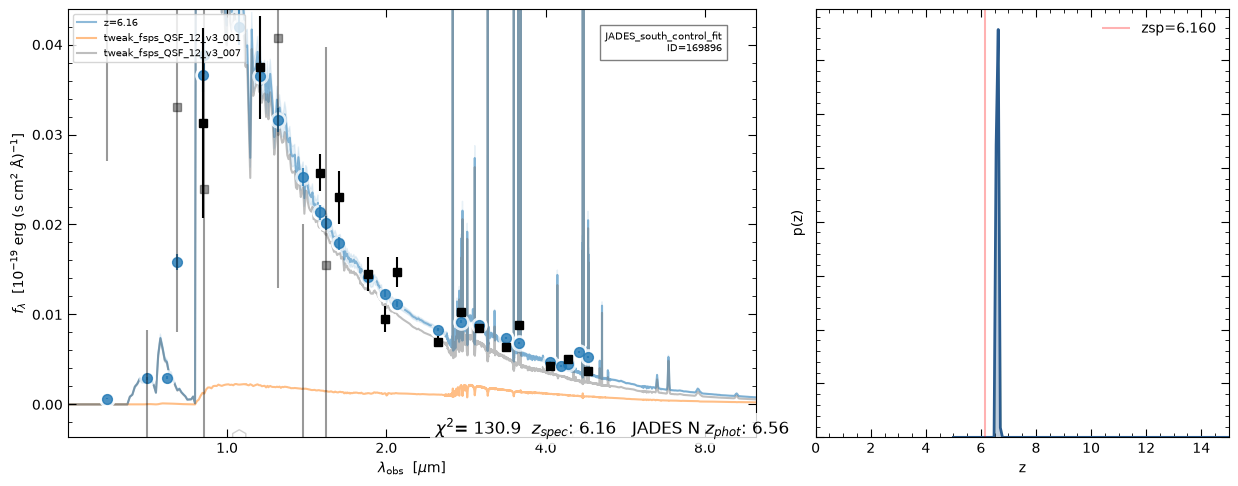

In [6]:
from matplotlib.ticker import AutoMinorLocator

output_path = '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/Tweak Fitting/JADES_south_control_fit.zout.fits'
output_data = Table.read(output_path)

ids_index = []
for i in range(len(ids)):
    n = np.where(zout['id']==ids[i])[0]
    ids_index.append(n.item())
print(ids_index)

for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[.5, 10], show_components=True,
                            logpz=False, zr=[0,15])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()
    
    #fig.axes[0].set_ylim(0, 0.13)

    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)

    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 

4.722185e+00
9.414404e-01
8.643539e-01
1.085727e+00
1.017488e+00
9.750484e-01
2.330950e+00
8.741724e-01
7.863629e-01
6.646870e-01
7.941518e-01
2.157311e+00
2.023087e+00


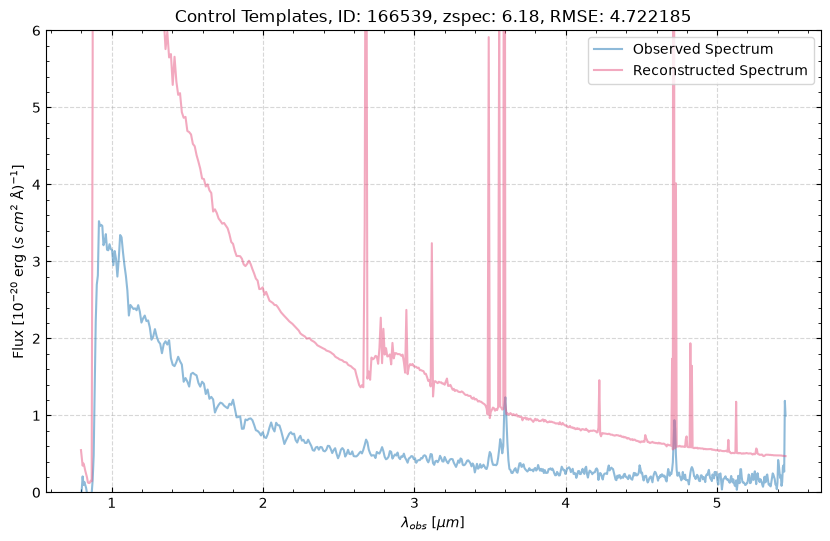

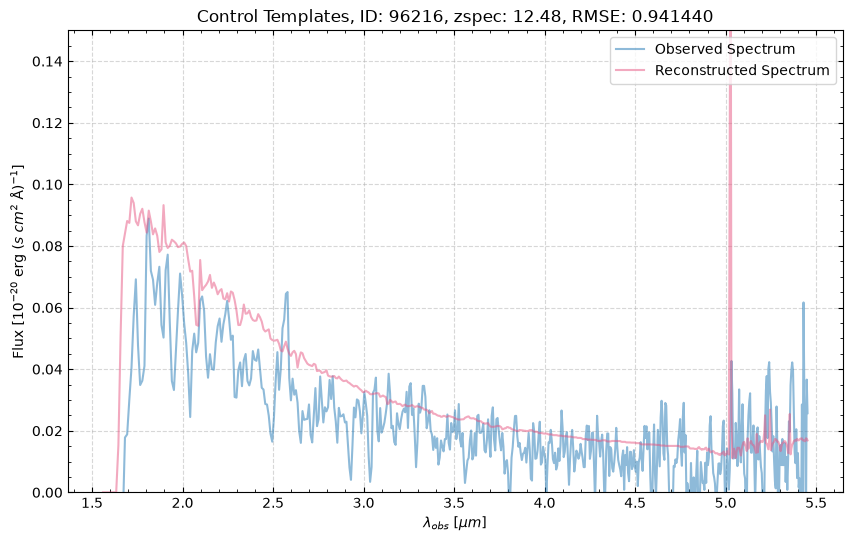

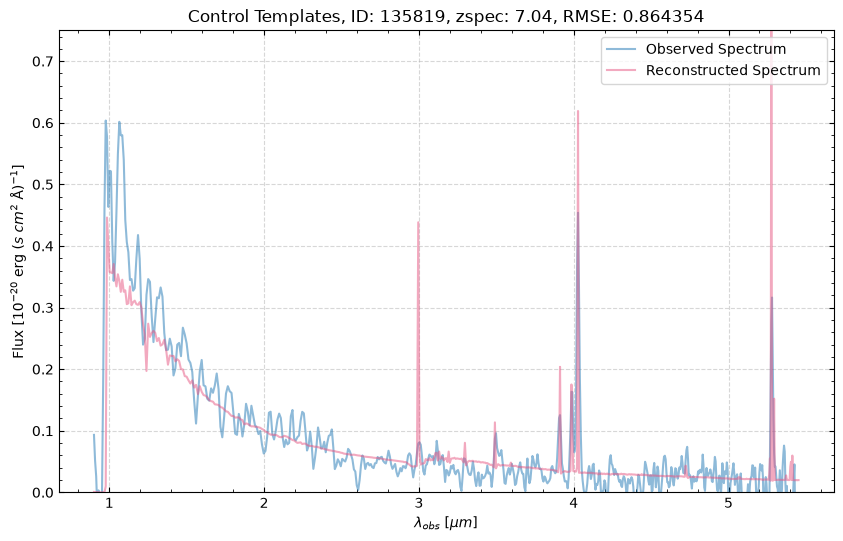

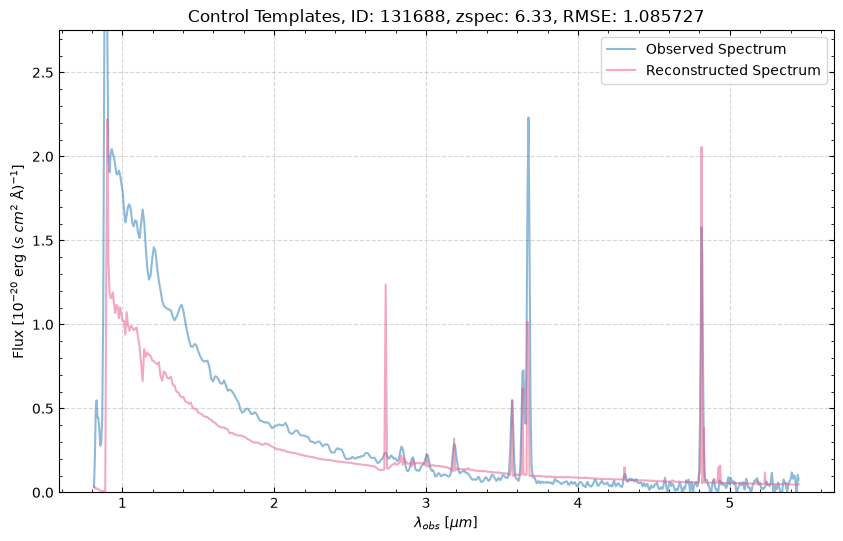

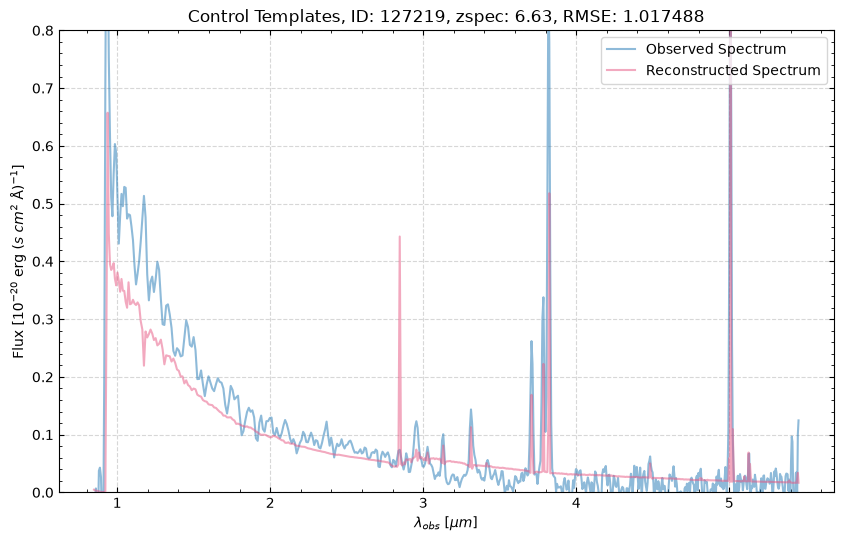

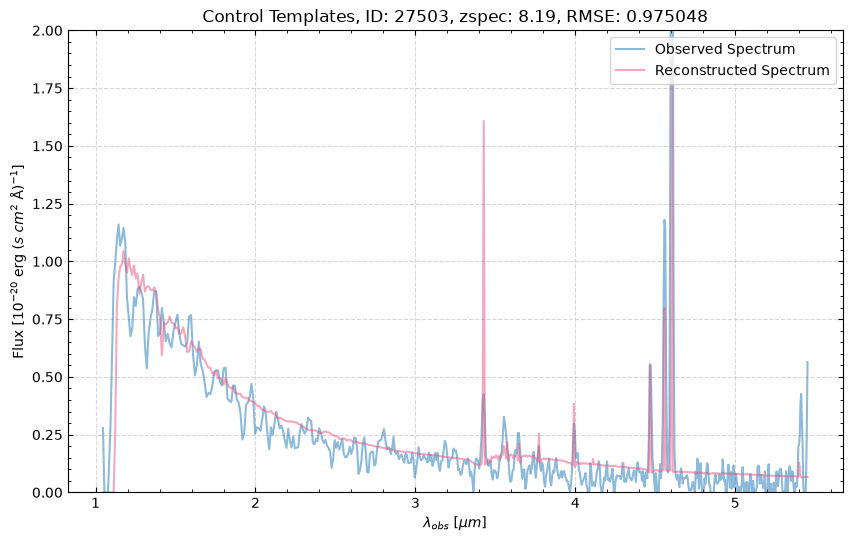

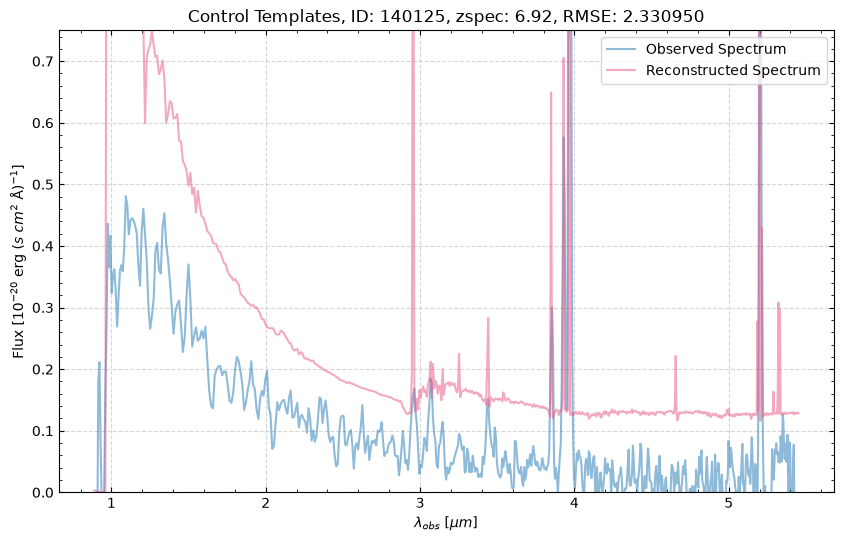

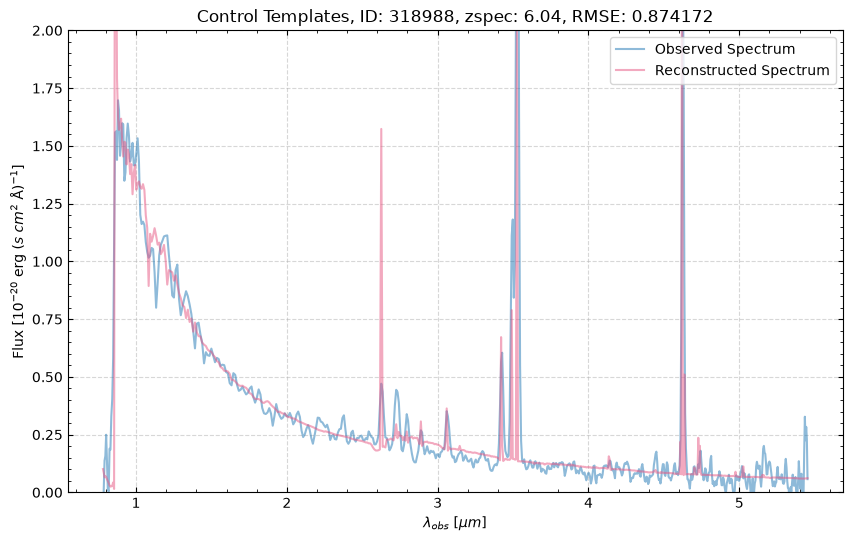

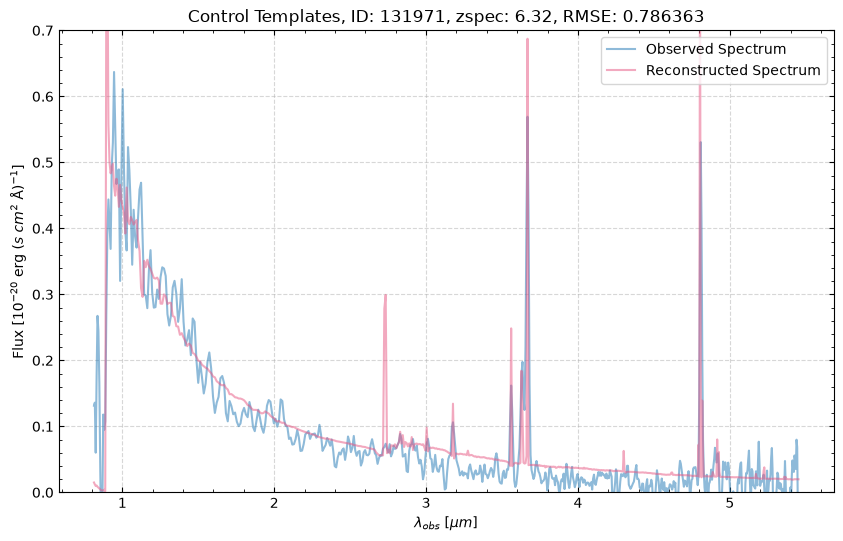

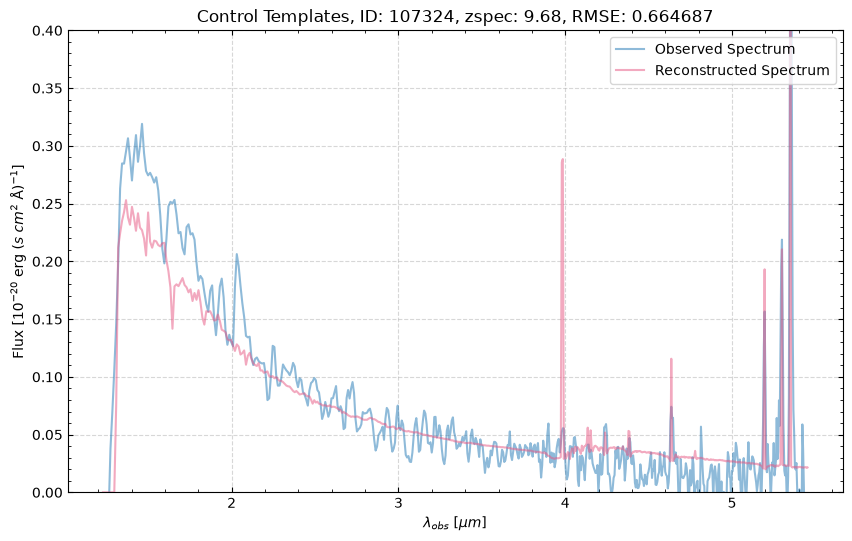

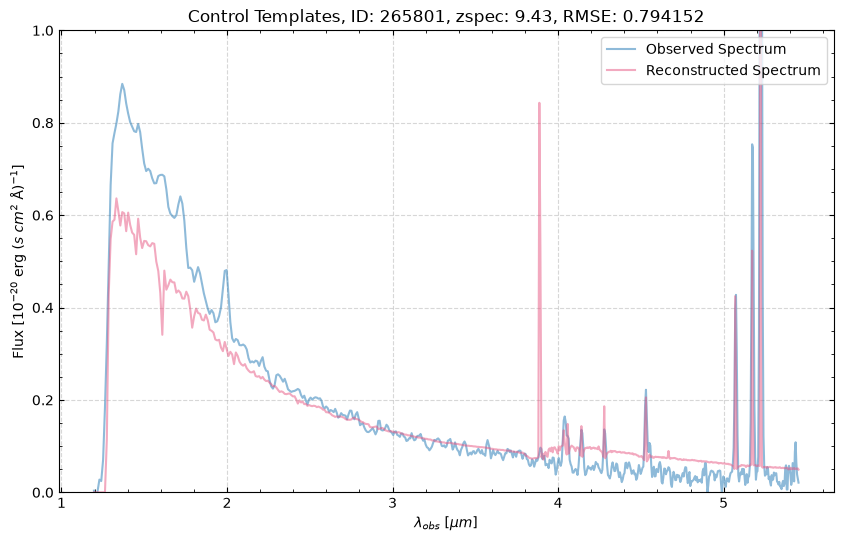

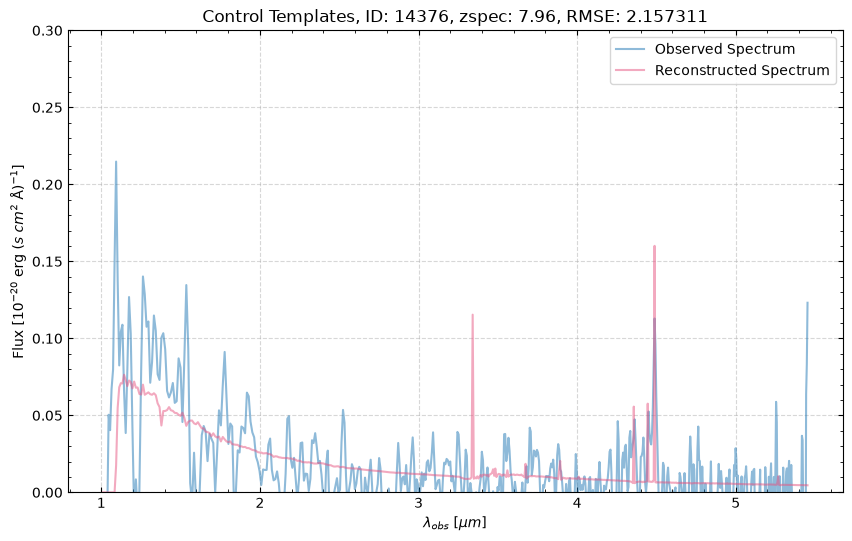

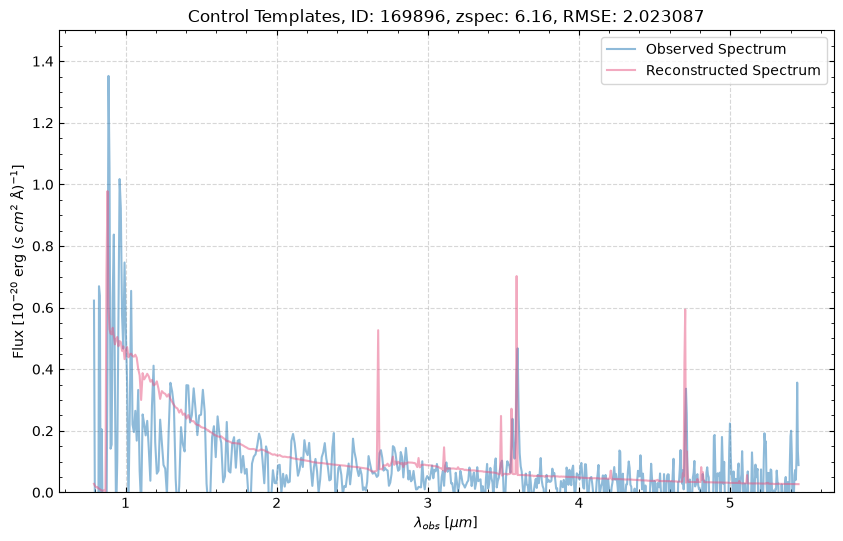

In [7]:
from spectres import spectres
import warnings
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')

paths = [
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-mediumjwst-166539_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-ultradeep-96216_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-deephst-135819_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-deephst-131688_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-deephst-127219_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-mediumjwst-27503_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-deephst-140125_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-deepjwst-318988_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-deephst-131971_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-deephst-107324_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra/hlsp_jades_jwst_nirspec_goods-s-ultradeep-265801_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra_out/hlsp_jades_jwst_nirspec_goods-s-deepjwst-14376_clear-prism_v1.0_x1d.fits',
    '/home/caltech-msanche3/data/south_spectra_out/hlsp_jades_jwst_nirspec_goods-s-mediumjwst-169896_clear-prism_v1.0_x1d.fits'
]
ylims = [6,1.5e-1,.75,2.75,.8,2,.75,2,7e-1,.4,1,3e-1,1.5]
nrmsers = []
for i in range(len(ids)):
    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0)
    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)
    #flux_model = sed_data['templf']*1e-19 # Best-fit template flux density
    flux_model = sed_data['templf']*10

    data = Table.read(paths[i])
    wave_obs = data['WAVELENGTH']
    #flux_obs = data['FLUX']
    flux_obs = data['FLUX']/1e-20
    err_obs = data['FLUX_ERR']

    flux_model_interp = spectres(
        wave_obs,                # Target wavelength
        wave_model,              # model wavelength grid
        flux_model,             #  model flux
        fill=np.nan,             # Fill value for out-of-bounds wavelengths
        verbose=False
    )
    
    mask = (wave_obs > (.1216*(1+zspec[i]))-.08)

    rmse = np.sqrt(np.mean((flux_model_interp[mask] - flux_obs[mask])**2))
    nrmse = rmse / np.mean(flux_obs[mask])
    nrmsers.append(nrmse)

    fig,ax = plt.subplots(figsize=(10,6))
    ax.plot(wave_obs[mask],flux_obs[mask],alpha=0.5)
    ax.plot(wave_obs[mask],flux_model_interp[mask],alpha=0.5,c='#E75480')
    ax.set_xlabel(r'$\lambda_{obs} \text{ }[\mu m]$')
    ax.set_ylabel(r'Flux [$10^{-20}$ erg $(s \text{ } cm^2 \text{ } \mathrm{\AA})^{-1}]$')
    # xlim just used to look at lyman break up close
    #ax.set_xlim(0.8,.9)
    ax.set_ylim(0,ylims[i])
    ax.set_title(f'Control Templates, ID: {ids[i]}, zspec: {zspec[i]}, RMSE: {nrmsers[i]:1f}')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
    ax.legend(['Observed Spectrum','Reconstructed Spectrum'],loc='upper right')
    ax.minorticks_on()

for rms in nrmsers:
    print(f'{rms:1e}')

    

In [8]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
# 1. The redshift evaluation grid (1D array)
zgrid = ez.zgrid

# 2. Extract the log-likelihood array
# Shape is (NOBJ, NZ) where NOBJ is catalog size, NZ is length of zgrid
lnp = ez.lnp

# 3. Convert log-likelihood to likelihood probability distribution P(z)
# Shift by max(lnp) per object before exponentiating to avoid numerical underflow
p_z = np.exp(lnp - np.max(lnp, axis=1, keepdims=True))

# 4. Normalize P(z) so the integral over z equals 1
p_z_norm = p_z / np.trapezoid(p_z, zgrid, axis=1)[:, np.newaxis]

z_lo = []
z_hi = []
for i in range(len(ids_index)):
    #if ids[i] == 159179:
        #continue

    cdf = cumulative_trapezoid(p_z_norm[ids_index][i], zgrid, initial=0)
    # Normalize CDF strictly to 1.0 just in case
    cdf /= cdf[-1]

    # 3. Interpolate to find the z values corresponding to the target percentiles
    z_16 = np.interp(0.16, cdf, zgrid)
    n = zout[ids_index][i]['z_phot'] - z_16
    z_lo.append(np.round(n,3).item())
    #z_50 = np.interp(0.50, cdf, zgrid)  # will use z_phot instead
    z_84 = np.interp(0.84, cdf, zgrid)
    n = z_84 - zout[ids_index][i]['z_phot']
    z_hi.append(np.round(n,3).item())

    #print(f"Redshift 16th percentile (z_16): {z_16:.3f}")
    #print(f"Chi^2 z_phot: {zout[ids_index][i]['z_phot']:.3f}")
    #print(f"Redshift 84th percentile (z_84): {z_84:.3f}")
    #print(f"1-sigma lower/upper bounds: z = {zout[ids_index][i]['z_phot']:.3f} +{z_84 - zout[ids_index][i]['z_phot']:.3f} -{zout[ids_index][i]['z_phot'] - z_16:.3f}")
    #print()
print(z_lo)
print(z_hi)
print(len(z_lo))


[-0.208, -0.068, -0.139, 0.129, 0.141, 0.197, -0.44, 0.175, 0.038, 0.459, -0.409, 0.221, -0.375]
[0.333, 1.149, 0.303, -0.02, -0.031, -0.047, 0.563, 0.067, 0.077, -0.315, 0.676, 0.104, 0.505]
13


[6.179999828338623, 12.479999542236328, 7.039999961853027, 6.329999923706055, 6.630000114440918, 8.1899995803833, 6.920000076293945, 6.039999961853027, 6.320000171661377, 9.680000305175781, 9.430000305175781, 7.960000038146973, 6.159999847412109]
[[-0.208, -0.068, -0.139, 0.129, 0.141, 0.197, -0.44, 0.175, 0.038, 0.459, -0.409, 0.221, -0.375], [0.333, 1.149, 0.303, -0.02, -0.031, -0.047, 0.563, 0.067, 0.077, -0.315, 0.676, 0.104, 0.505]]


ValueError: 'yerr' must not contain negative values

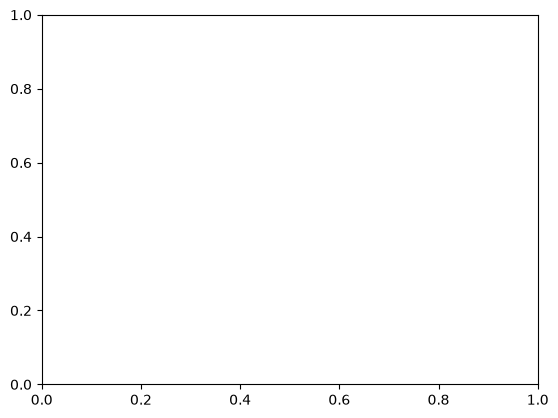

In [9]:
eazy_zphot = []
for i in range(len(ids_index)):
    n=output_data[ids_index[i]]['z_phot']
    eazy_zphot.append(np.round(n,3).item())
print(eazy_zphot)
err = [z_lo,z_hi]



fig,ax = plt.subplots()
x = np.linspace(5,14,10)
y = np.linspace(5,14,10)
#ax.scatter(eazy_zphot,zspec,c='r',s=3)
print(err)

plt.errorbar(zspec, eazy_zphot, yerr=err, fmt='s',c='k',ms=5,elinewidth=1,alpha=0.9)
#ax.scatter(zspec,ceers_zphot,c='b',s=3)
#ax.scatter(zspec,ceers_zmed,c='b',s=3)
#plt.errorbar(zspec, ceers_zmed, yerr=ceers_err, fmt='s',c='b',ms=3,elinewidth=1,alpha=0.5)
ax.plot(x,y,alpha=0.3,c='k',linestyle='--')
ax.set_ylim(5,14)
ax.set_xlim(5,14)
ax.set_xlabel(r'$z_{spec}$')
ax.set_ylabel(r'$z_{phot}$')


ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend([r'$z_{phot} = z_{spec}$ line',"Control Template"])
plt.tight_layout()

Average Tweak Templates z_phot absolute error: 3.117e-02


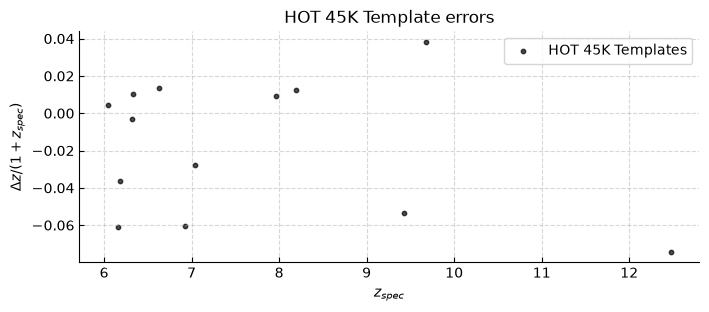

In [ ]:
eazy_err = []
for i in range(len(zspec)):
    eazy_err.append((zspec[i]-eazy_zphot[i])/(1+zspec[i]))

print(f"Average Tweak Templates z_phot absolute error: {np.mean(np.abs(eazy_err)):.3e}")

fig,ax = plt.subplots(figsize=(8,3))
ax.scatter(zspec,eazy_err,alpha=0.7,c='k',s=10)
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("HOT 45K Template errors")
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.set_xlabel(r"$z_{spec}$")
ax.set_ylabel(r"$\Delta z/(1+z_{spec})$")
ax.legend(["HOT 45K Templates"])



[np.float64(9.702163190934613), np.float64(9.976156606547198), np.float64(8.67942591916394), np.float64(8.621806770002324), np.float64(8.207603389287536), np.float64(8.924668521039845), np.float64(9.82824008968263), np.float64(8.808354868524548), np.float64(8.294812799834492), np.float64(8.572794137927934), np.float64(8.969697952685145), np.float64(7.754993600878638), np.float64(8.628160202199487)]


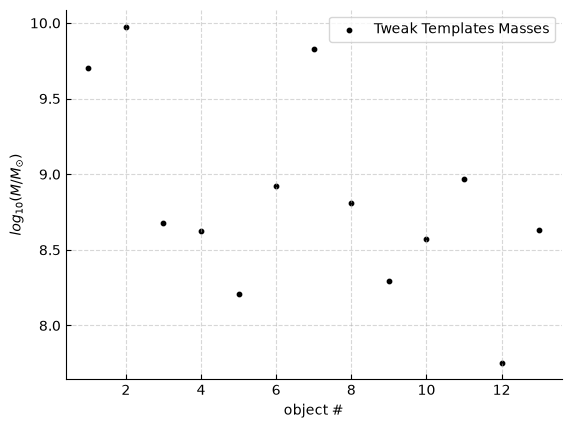

In [ ]:
eazy_mass = []
n=len(zspec)
x = np.linspace(1,n,n)
for i in range(len(ids_index)):
    eazy_mass.append(np.log10(output_data[ids_index[i]]['mass']))
fig,ax = plt.subplots()
ax.scatter(x,eazy_mass,c='k',s=10)
ax.set_xlabel('object #')
ax.set_ylabel(r'$log_{10}(M/M_{\odot})$')
ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["Tweak Templates Masses"])
print(eazy_mass)